<a href="https://colab.research.google.com/github/PromitMukherjee/Machine_learning_Algorithm/blob/main/Supervised_Learning/Polynomial_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [11]:
# ============================================================
# Polynomial Feature Generator
# ============================================================

def polynomial_features(X, degree):

    X = np.asarray(X, dtype=np.float64)

    # For one-dimensional X
    X_poly = np.column_stack([
        X[:, 0] ** i
        for i in range(1, degree + 1)
    ])

    return X_poly

In [12]:
# ============================================================
# Polynomial Regression using Normal Equation
# ============================================================

class PolynomialRegressionNormal:

    def __init__(self, degree=2):

        self.degree = degree
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):

        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)

        # Create polynomial features
        X_poly = polynomial_features(X, self.degree)

        # Add bias column
        X_b = np.c_[
            np.ones((X_poly.shape[0], 1)),
            X_poly
        ]

        # Normal Equation
        theta = np.linalg.inv(
            X_b.T @ X_b
        ) @ X_b.T @ y

        self.intercept_ = theta[0]
        self.coef_ = theta[1:]

        return self

    def predict(self, X):

        X = np.asarray(X, dtype=np.float64)

        X_poly = polynomial_features(
            X,
            self.degree
        )

        return (
            X_poly @ self.coef_
            + self.intercept_
        )

    def score(self, X, y):

        y_pred = self.predict(X)

        ss_res = np.sum(
            (y - y_pred) ** 2
        )

        ss_tot = np.sum(
            (y - np.mean(y)) ** 2
        )

        return 1 - ss_res / ss_tot

In [13]:
# ============================================================
# Polynomial Regression using Gradient Descent
# ============================================================

class PolynomialRegressionGD:

    def __init__(
        self,
        degree=2,
        learning_rate=0.00001,
        n_iterations=10000
    ):

        self.degree = degree
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations

        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):

        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)

        # Create polynomial features
        X_poly = polynomial_features(
            X,
            self.degree
        )

        n_samples, n_features = X_poly.shape

        # Initialize parameters
        self.coef_ = np.zeros(n_features)
        self.intercept_ = 0.0

        # Gradient Descent
        for _ in range(self.n_iterations):

            y_pred = (
                X_poly @ self.coef_
                + self.intercept_
            )

            error = y_pred - y

            # Gradient for coefficients
            dw = (
                1 / n_samples
            ) * (
                X_poly.T @ error
            )

            # Gradient for intercept
            db = (
                1 / n_samples
            ) * np.sum(error)

            # Update parameters
            self.coef_ -= (
                self.learning_rate * dw
            )

            self.intercept_ -= (
                self.learning_rate * db
            )

        return self

    def predict(self, X):

        X = np.asarray(X, dtype=np.float64)

        X_poly = polynomial_features(
            X,
            self.degree
        )

        return (
            X_poly @ self.coef_
            + self.intercept_
        )

    def score(self, X, y):

        y_pred = self.predict(X)

        ss_res = np.sum(
            (y - y_pred) ** 2
        )

        ss_tot = np.sum(
            (y - np.mean(y)) ** 2
        )

        return 1 - ss_res / ss_tot

In [14]:
# ============================================================
# Dataset
# ============================================================

X = np.array([
    [1],
    [2],
    [3],
    [4],
    [5],
    [6],
    [7],
    [8],
    [9],
    [10]
], dtype=np.float64)

# Polynomial relationship
# y = x² + 2x + 1

y = np.array([
    4,
    9,
    16,
    25,
    36,
    49,
    64,
    81,
    100,
    121
], dtype=np.float64)

In [15]:
# ============================================================
# Degree of Polynomial
# ============================================================

degree = 2


# ============================================================
# Train Normal Equation
# ============================================================

normal_model = PolynomialRegressionNormal(
    degree=degree
)

start_time = time.perf_counter()

normal_model.fit(X, y)

normal_time = time.perf_counter() - start_time


# ============================================================
# Train Gradient Descent
# ============================================================

gd_model = PolynomialRegressionGD(
    degree=degree,
    learning_rate=0.00001,
    n_iterations=10000
)

start_time = time.perf_counter()

gd_model.fit(X, y)

gd_time = time.perf_counter() - start_time

In [16]:
# ============================================================
# Predictions
# ============================================================

normal_pred = normal_model.predict(X)

gd_pred = gd_model.predict(X)


# ============================================================
# Accuracy Metrics
# ============================================================

normal_r2 = normal_model.score(X, y)

gd_r2 = gd_model.score(X, y)


normal_mse = np.mean( (y - normal_pred) ** 2 )

gd_mse = np.mean( (y - gd_pred) ** 2 )

In [17]:
# ============================================================
# Display Results
# ============================================================

print("=" * 70)
print("POLYNOMIAL REGRESSION COMPARISON")
print("=" * 70)

print("\nPolynomial Degree:", degree)


# ------------------------------------------------------------
# Normal Equation
# ------------------------------------------------------------

print("\nNormal Equation")
print("-" * 40)

print("Intercept:", normal_model.intercept_)

print("Coefficients:", normal_model.coef_ )

print("R² Score:", normal_r2 )

print("MSE:", normal_mse )

print("Training Time:", normal_time, "seconds")

print("Prediction for X=11:", normal_model.predict([[11]]) )


# ------------------------------------------------------------
# Gradient Descent
# ------------------------------------------------------------

print("\nGradient Descent")
print("-" * 40)

print("Intercept:", gd_model.intercept_)

print("Coefficients:",gd_model.coef_)

print("R² Score:",gd_r2)

print("MSE:",gd_mse)

print("Training Time:",gd_time,"seconds")

print("Prediction for X=11:",gd_model.predict([[11]]))


# ============================================================
# Comparison Table
# ============================================================

print("\n" + "=" * 70)
print("COMPARISON")
print("=" * 70)

print(
    f"{'Metric':<25}"
    f"{'Normal Equation':<22}"
    f"{'Gradient Descent':<22}"
)

print("-" * 70)

print(
    f"{'R² Score':<25}"
    f"{normal_r2:<22.6f}"
    f"{gd_r2:<22.6f}"
)

print(
    f"{'MSE':<25}"
    f"{normal_mse:<22.6f}"
    f"{gd_mse:<22.6f}"
)

print(
    f"{'Training Time':<25}"
    f"{normal_time:<22.8f}"
    f"{gd_time:<22.8f}"
)

POLYNOMIAL REGRESSION COMPARISON

Polynomial Degree: 2

Normal Equation
----------------------------------------
Intercept: 1.0000000000006395
Coefficients: [2. 1.]
R² Score: 1.0
MSE: 3.3093819379288755e-25
Training Time: 0.0003013839999539414 seconds
Prediction for X=11: [144.]

Gradient Descent
----------------------------------------
Intercept: 0.2004035991701422
Coefficients: [0.60473149 1.17895755]
R² Score: 0.9952245548459077
MSE: 6.910307910229378
Training Time: 0.2325456529999883 seconds
Prediction for X=11: [149.50631301]

COMPARISON
Metric                   Normal Equation       Gradient Descent      
----------------------------------------------------------------------
R² Score                 1.000000              0.995225              
MSE                      0.000000              6.910308              
Training Time            0.00030138            0.23254565            


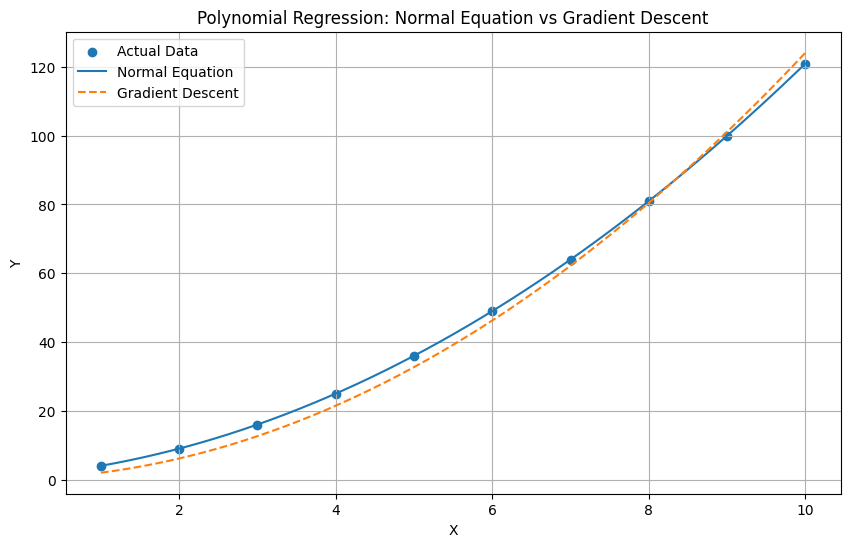

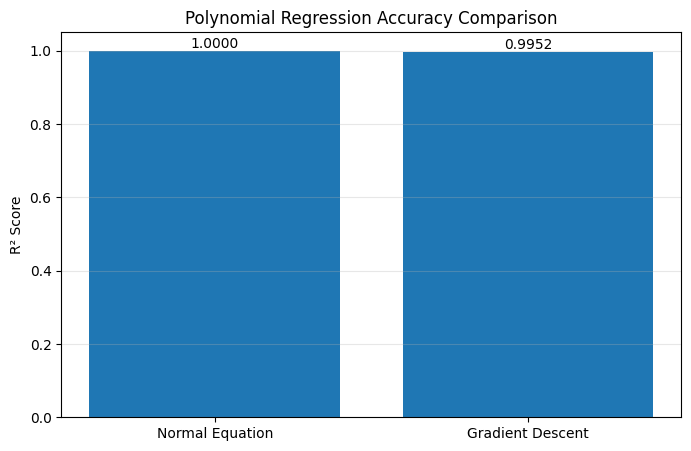

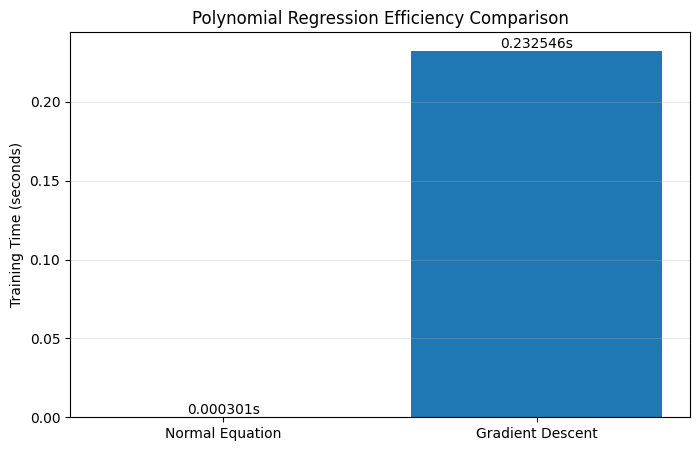

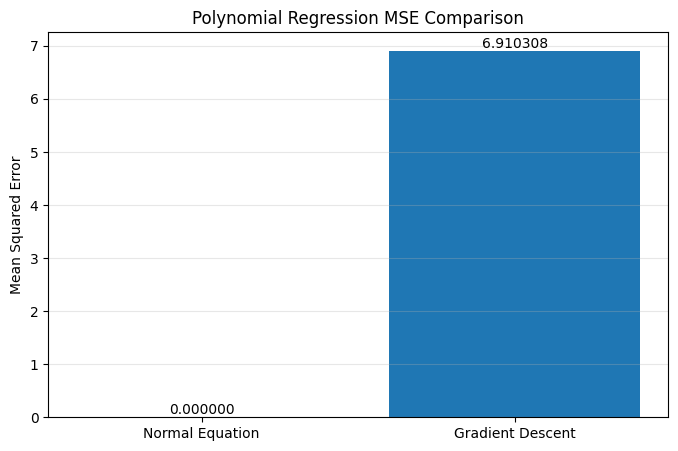

In [18]:
# ============================================================
# Generate Smooth Curve
# ============================================================

X_line = np.linspace(
    X.min(),
    X.max(),
    200
).reshape(-1, 1)


normal_line = normal_model.predict(
    X_line
)

gd_line = gd_model.predict(
    X_line
)


# ============================================================
# Plot 1: Polynomial Regression Curves
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    X,
    y,
    label="Actual Data"
)

plt.plot(
    X_line,
    normal_line,
    label="Normal Equation"
)

plt.plot(
    X_line,
    gd_line,
    linestyle="--",
    label="Gradient Descent"
)

plt.xlabel("X")
plt.ylabel("Y")

plt.title(
    "Polynomial Regression: Normal Equation vs Gradient Descent"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# Plot 2: Accuracy Comparison
# ============================================================

methods = [
    "Normal Equation",
    "Gradient Descent"
]

r2_scores = [
    normal_r2,
    gd_r2
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    methods,
    r2_scores
)

plt.ylabel("R² Score")

plt.title(
    "Polynomial Regression Accuracy Comparison"
)

plt.ylim(0, 1.05)

for bar, value in zip(
    bars,
    r2_scores
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ============================================================
# Plot 3: Efficiency Comparison
# ============================================================

training_times = [
    normal_time,
    gd_time
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    methods,
    training_times
)

plt.ylabel(
    "Training Time (seconds)"
)

plt.title(
    "Polynomial Regression Efficiency Comparison"
)

for bar, value in zip(
    bars,
    training_times
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.6f}s",
        ha="center",
        va="bottom"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ============================================================
# Plot 4: MSE Comparison
# ============================================================

mse_values = [
    normal_mse,
    gd_mse
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    methods,
    mse_values
)

plt.ylabel("Mean Squared Error")

plt.title(
    "Polynomial Regression MSE Comparison"
)

for bar, value in zip(
    bars,
    mse_values
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.6f}",
        ha="center",
        va="bottom"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

## Polynomial Regression Model Audit Report

### 1. Introduction

This report provides an audit of two polynomial regression models: the Normal Equation method and the Gradient Descent method. Both models were trained on the same dataset to predict a polynomial relationship (y = x² + 2x + 1) with a polynomial degree of 2.

### 2. Model Parameters

*   **Polynomial Degree:** 2
*   **Normal Equation Model:**
    *   Intercept: `1.0000000000006395`
    *   Coefficients: `[2. 1.]`
*   **Gradient Descent Model:**
    *   Learning Rate: `0.00001`
    *   Number of Iterations: `10000`
    *   Intercept: `0.2004035991701422`
    *   Coefficients: `[0.60473149 1.17895755]`

### 3. Performance Metrics

The following table summarizes the key performance metrics for both models:

| Metric              | Normal Equation | Gradient Descent |
| :------------------ | :-------------- | :--------------- |
| R² Score            | 1.000000        | 0.995225         |
| MSE                 | 0.000000        | 6.910308         |
| Training Time (s)   | 0.00030138      | 0.23254565       |

### 4. Analysis and Observations

*   **R² Score:** The Normal Equation achieved a perfect R² score of 1.0, indicating that it perfectly captured the underlying polynomial relationship in the training data. The Gradient Descent model also performed very well with an R² score of 0.995225, but slightly less accurately.
*   **Mean Squared Error (MSE):** The Normal Equation exhibited an extremely low MSE (practically zero), further confirming its precise fit. The Gradient Descent model had a higher MSE of 6.910308, suggesting some residual error.
*   **Training Time:** The Normal Equation was significantly faster to train, completing in approximately 0.0003 seconds. The Gradient Descent model took considerably longer, at approximately 0.2325 seconds for 10,000 iterations.
*   **Coefficients:** The Normal Equation derived coefficients (`[2. 1.]`) and an intercept (`1.0`) that very closely match the true parameters of the generated data (`y = x^2 + 2x + 1` translates to coefficients for x^2 and x being 1 and 2 respectively, and an intercept of 1 when features are handled as x^2, x^1, x^0). The Gradient Descent coefficients (`[0.60473149 1.17895755]`) and intercept (`0.2004035991701422`) show a noticeable deviation, indicating it did not fully converge to the optimal solution within the given iterations and learning rate.

### 5. Conclusion

For this specific dataset and polynomial degree, the **Normal Equation** proved to be superior in terms of both accuracy (perfect R² score and minimal MSE) and efficiency (much faster training time). The **Gradient Descent** model, while performing well, did not achieve the same level of precision or speed. This difference is expected, as the Normal Equation provides a direct analytical solution, whereas Gradient Descent is an iterative optimization algorithm that can be sensitive to learning rate and number of iterations.